### Eda in Pandas data frame and duckdb event's in stockholm

In [76]:
# import necessary tool's for this EDA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import duckdb

#### setup and load data file (events_combined.csv)

In [77]:
# load data using Pathlib

# finde's project root and returns  working directory
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "eda":
    PROJECT_ROOT = PROJECT_ROOT.parent

# build's path to the data file and reads into a DataFrame
DATA_PATH = PROJECT_ROOT / "app" / "data" / "output" / "events_combined.csv"
df = pd.read_csv(DATA_PATH)
df.head()

df.head().to_dict()

# sets clean default style and default figure size
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] =(10, 5)

In [78]:
# converting date column from string too real datetime values
df["date"] = pd.to_datetime(df["date"], errors="coerce")
print(df["date"].dtype)
print(df["date"].min(), "->", df["date"].max())

datetime64[us]
2026-04-14 00:00:00 -> 2027-12-22 00:00:00


In [79]:
# inspect shape and types of the dataset
print("Shape:", df.shape)
print("Dtypes:", df.dtypes)

Shape: (1221, 21)
Dtypes: event_id                    str
name                        str
url                         str
image_url                   str
date             datetime64[us]
time                        str
status                      str
segment                     str
genre                       str
subgenre                    str
venue_name                  str
venue_city                  str
venue_address               str
venue_lat               float64
venue_lon               float64
day_of_week                 str
month_name                  str
month_num                 int64
year                      int64
hour                    float64
source                      str
dtype: object


#### Data quality check

In [80]:
# checking for missing values per column

print("Missing Values per column:")
print(df.isna().sum())

# checking for duplicated rows
print("\nDuplicate rows:", df.duplicated().sum())
print("Duplicate event_ids:", df["event_id"].duplicated().sum())

# quick statistics on numeric columns
print("\nNumeric summary:")
df.describe()

Missing Values per column:
event_id          83
name               0
url                0
image_url          0
date               0
time             579
status             0
segment            0
genre              0
subgenre         275
venue_name        16
venue_city        18
venue_address      5
venue_lat          0
venue_lon          0
day_of_week        0
month_name         0
month_num          0
year               0
hour             579
source             0
dtype: int64

Duplicate rows: 0
Duplicate event_ids: 82

Numeric summary:


,date,venue_lat,venue_lon,month_num,year,hour
count,1221,1221.000000,1221.000000,1221.000000,1221.000000,642.000000
mean,2026-07-10 23:44:40.098280,59.352336,18.105719,6.443079,2026.029484,18.071651
min,2026-04-14 00:00:00,58.957408,17.398113,1.000000,2026.000000,0.000000
25%,2026-05-01 00:00:00,59.313946,18.055700,4.000000,2026.000000,18.000000
50%,2026-05-28 00:00:00,59.324570,18.073840,5.000000,2026.000000,19.000000
75%,2026-09-25 00:00:00,59.333999,18.096259,9.000000,2026.000000,20.000000
max,2027-12-22 00:00:00,59.993330,18.920662,12.000000,2027.000000,23.000000
std,NaN,0.136704,0.177921,2.641301,0.169228,2.959610


#### Most popular event hours

In [81]:
# SQL aggregation (it runs directly on the pandas df)

# witch hour of the day hase the most events
duckdb.sql("""
    SELECT
        hour ,
        count(*) AS num_events
    From df
    WHERE hour IS NOT NULL
    GROUP BY hour
    ORDER BY num_events DESC
""")

┌────────┬────────────┐
│  hour  │ num_events │
│ double │   int64    │
├────────┼────────────┤
│   19.0 │        207 │
│   20.0 │        167 │
│   18.0 │        125 │
│   15.0 │         46 │
│   16.0 │         24 │
│   13.0 │         20 │
│   17.0 │         12 │
│   11.0 │         10 │
│    0.0 │          8 │
│   21.0 │          7 │
│   22.0 │          6 │
│   14.0 │          5 │
│   23.0 │          3 │
│    1.0 │          1 │
│   12.0 │          1 │
└────────┴────────────┘
  15 rows   2 columns

### Time of the day varchar

In [82]:
# putting events hours into four parts of the day
duckdb.sql("""
    SELECT
        CASE
            WHEN hour BETWEEN 6 AND 11 THEN 'Morning'
            WHEN hour BETWEEN 12 AND 17 THEN 'Afternoon'
            WHEN hour BETWEEN 18 AND 22 THEN 'Evening'
            ELSE 'Late night'
        END AS time_of_day
        FROM df
        WHERE hour IS NOT NULL
        GROUP BY time_of_day
        ORDER BY COUNT(*) DESC
""")

┌─────────────┐
│ time_of_day │
│   varchar   │
├─────────────┤
│ Evening     │
│ Afternoon   │
│ Late night  │
│ Morning     │
└─────────────┘

#### Events per month (matplotlib bar chart)

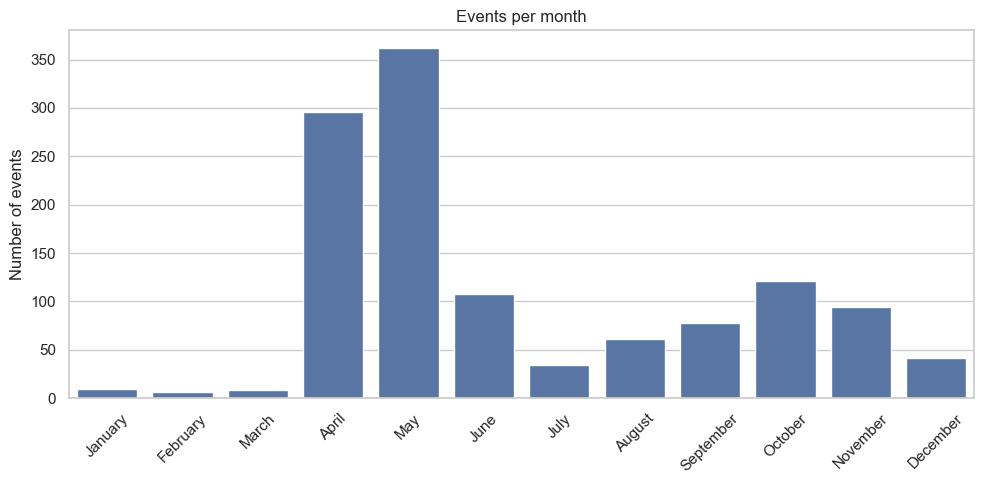

In [83]:
# cunts evens per month name
month_order = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

# forcing the month on calendar order
events_per_month = df["month_name"].value_counts().reindex(month_order, fill_value=0)

# draws the bars
fig, ax = plt.subplots()
sns.barplot(x=month_order, y=events_per_month, ax=ax)
ax.set_title("Events per month")
ax.set_ylabel("Number of events")
ax.set_xlabel("")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

### events per week ( bar chart )

saved: /Users/lillmossi/Documents/github/Visualization_project/app/data/output/imag


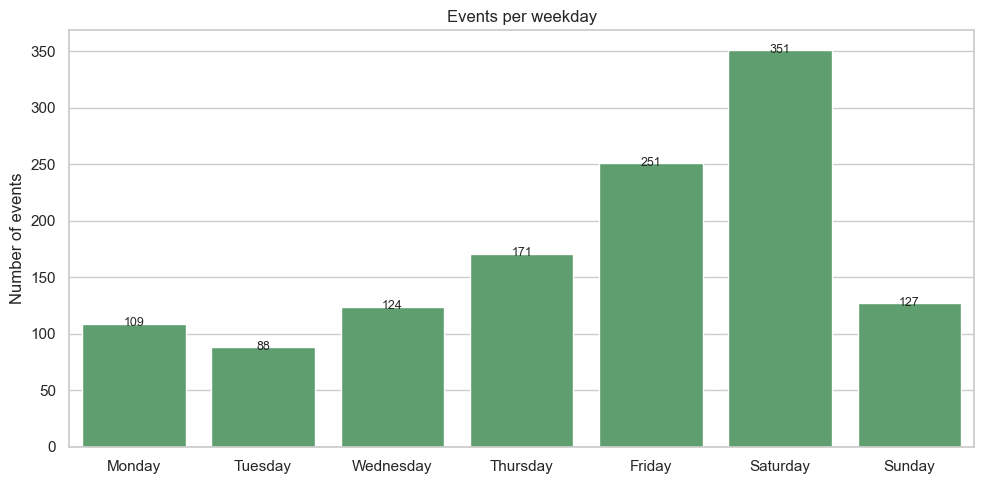

In [84]:

weekday_order = ["Monday", "Tuesday", "Wednesday",
                 "Thursday", "Friday", "Saturday", "Sunday"]

events_per_weekday = df["day_of_week"].value_counts().reindex(weekday_order, fill_value=0)

# draw chart
fig, ax = plt.subplots()
sns.barplot(x=events_per_weekday.index, y=events_per_weekday.values, ax=ax, color="#55A868") # style choice
ax.set_title("Events per weekday")
ax.set_ylabel("Number of events")
ax.set_xlabel("")

#count labels are above each bar
for i, v in enumerate(events_per_weekday.values):
    ax.text(i, v + 0.3, str(v), ha="center", va="center", fontsize=9)

plt.tight_layout()
 # figure is saved to disk
imag_path = PROJECT_ROOT / "app" / "data" / "output" / "imag"
plt.savefig(imag_path, dpi=150, bbox_inches="tight")
print("saved:", imag_path)

plt.show()

#### Top 5 segments

In [85]:
# counts top five segment with pandas
top5_segments = df["segment"].value_counts().head(5)

# counts top five genres with Duckdb
top5_segments = duckdb.sql("""
    SELECT genre, COUNT(*) AS n_events
    FROM df
    GROUP BY genre
    ORDER BY n_events desc
    LIMIT 5
""")


saved -> /Users/lillmossi/Documents/github/Visualization_project/eda/data_images/top5_segments.png


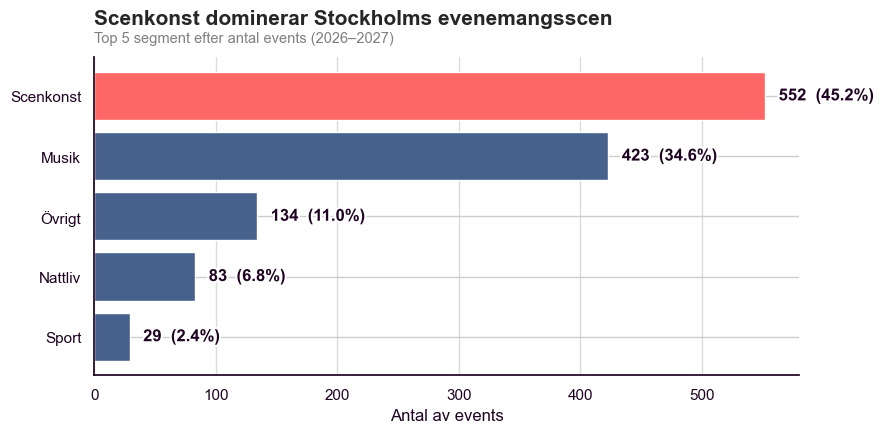

In [86]:
import matplotlib.patheffects as path_effects

# counts events per segment
top5_segments = (
    df["segment"]
    .value_counts()
    .head(5)
    .rename_axis("segment")
    .reset_index(name="n_events")
)

# translate to swedish for swedish audience
SEGMENT_SV = {
    "Arts & Theatre": "Scenkonst",
    "Music":          "Musik",
    "Miscellaneous":  "Övrigt",
    "Nightlife":      "Nattliv",
    "Sports":         "Sport",
}
# maps english segment names to swedish
top5_segments["segment"] = top5_segments["segment"].map(SEGMENT_SV)
plot_data = top5_segments.iloc[::-1].reset_index(drop=True)

# chart color style
PROJECT_COLORS = {
    "Scenkonst": "#FF6666",
    "Musik":     "#47618D",
    "Övrigt":    "#47618D",
    "Nattliv":   "#47618D",
    "Sport":     "#47618D",
}
bar_colors = plot_data["segment"].map(PROJECT_COLORS)

# building the figure
fig, ax = plt.subplots(figsize=(9, 4.5))

fig.patch.set_facecolor("#FFFFFF")
ax.set_facecolor("#FFFFFF")

# sets color for text
TEXT_COLOR = "#1F0322"
ax.title.set_color(TEXT_COLOR)
ax.xaxis.label.set_color(TEXT_COLOR)
ax.tick_params(colors=TEXT_COLOR)
for spine in ax.spines.values():
    spine.set_color(TEXT_COLOR)

# draw horizontal bars
bars = ax.barh(
    y=range(len(plot_data)),
    width=plot_data["n_events"],
    color=bar_colors,
    edgecolor="white",
    linewidth=1,
)
ax.set_yticks(range(len(plot_data)))
ax.set_yticklabels(plot_data["segment"])

# add count and makes it more readable
total = plot_data["n_events"].sum()
xmax  = plot_data["n_events"].max()
for bar, v in zip(bars, plot_data["n_events"]):
    pct = v / total * 100
    txt = ax.text(bar.get_width() + xmax * 0.02,
                  bar.get_y() + bar.get_height() / 2,
                  f"{v}  ({pct:.1f}%)",
                  va="center", fontsize=12, fontweight="bold", color=TEXT_COLOR)
    txt.set_path_effects([
        path_effects.Stroke(linewidth=3, foreground="#FFFFFF"),
        path_effects.Normal(),
    ])

# Add title
ax.set_title("Scenkonst dominerar Stockholms evenemangsscen",
             fontsize=15, fontweight="bold", loc="left", pad=24)

ax.text(0, 1.04, "Top 5 segment efter antal events (2026–2027)",
        transform=ax.transAxes, fontsize=10.5, color="gray",
        ha="left", va="bottom")

# strips y-axis label (segment name makes it obvious)
ax.set_xlabel("Antal av events")
ax.set_ylabel("")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="x", color=TEXT_COLOR, alpha=0.15)

plt.tight_layout()

# saves the image of the bar chartß
img_path = PROJECT_ROOT / "eda" / "data_images" / "top5_segments.png"
plt.savefig(img_path, dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
print(f"saved -> {img_path}")
plt.show()